# Example usage of ZTFCoords

This notebook gives a simple example of usage of ZTFfields functions linking focal plane coordinates to CCD and quadrant coordinates.

Be wary that this must not be used for science purposes but rather for imaging purposes, as the telescope drift is not taken into account in the mapping.

## Import modules

In [1]:
import ztffields as ztff
from ztffields.utils import ZTFCoords

## Import coefs

These coefficients are second degree polynomials fitted on many images with WCS as a conversion between (x,y) and (u,v)

In [2]:
# Initialize ZTFCoords object with h5 file
ztf_coords = ZTFCoords(h5file='./ztffields/data/uv_xy_coefs.h5')

## Compute coordinates in canonical ordering

### Preview canonical ordering with frame orientation

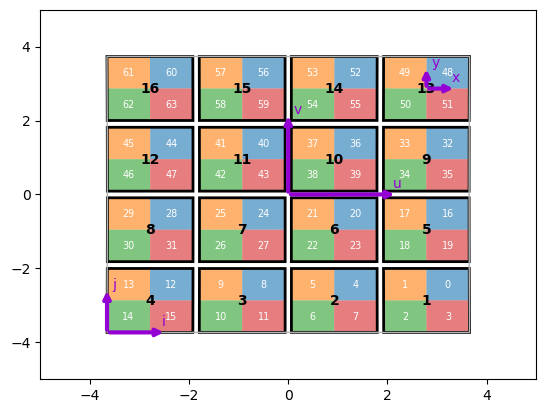

In [3]:
ztff.show_ztf_footprint(draw_arrows=True);

### Map coordinates between (x,y) and (u,v)

In [4]:
# Example: Convert (x,y) to (u,v)
rcid = 24
x, y = 100, 200  # Example RCID coordinates

# Convert (x,y) to (u,v)
u, v = ztf_coords.xy_to_uv(x, y, rcid)
print(f"Converted (x,y)={x},{y} to (u,v)={u[0]:.2f},{v[0]:.2f}")

# Example: Convert (u,v) back to (x,y)
x_recovered, y_recovered = ztf_coords.uv_to_xy(u, v, rcid)
print(f"Recovered (x,y)={x_recovered[0]:.2f},{y_recovered[0]:.2f}")

Converted (x,y)=100,200 to (u,v)=-3240.18,-3206.02
Recovered (x,y)=100.03,200.00


### Map coordinates between (i,j) and (u,v)

In [5]:
# Example: Convert (i,j) to (u,v)
ccdid = 4
i, j = 300, 100  # Example CCD coordinates

# Convert (i,j) to (u,v)
u, v = ztf_coords.ij_to_uv(i, j, ccdid)
print(f"Converted (i,j)={i},{j} to (u,v)={u[0]:.2f},{v[0]:.2f}")

# Example: Convert (u,v) back to (i,j)
i_recovered, j_recovered = ztf_coords.uv_to_ij(u, v, ccdid)
print(f"Recovered (i,j)={i_recovered[0]:.2f},{j_recovered[0]:.2f}")


Converted (i,j)=300,100 to (u,v)=-12859.74,-13367.46
Recovered (i,j)=300.03,100.00


## Comparison with WCS mapping

We use a science image from the 600 field to compare the xy to uv mapping using WCS and our new mapping

In [6]:
import ztfimg
from ztfquery import get_file

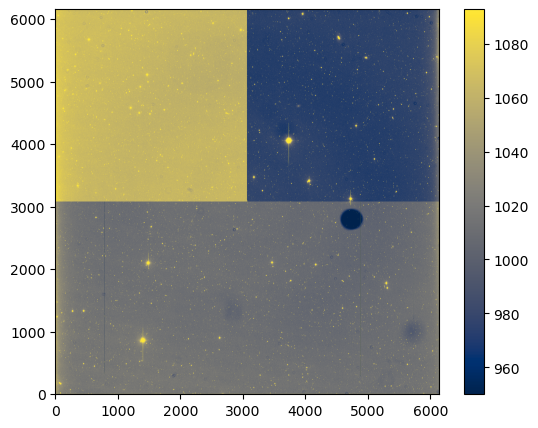

In [7]:
rawfile = get_file("ztf_20251107317118_000600_zr_c06_o.fits.fz", show_progress=False)
raw = ztfimg.RawCCD.from_filename(rawfile)
raw.show();

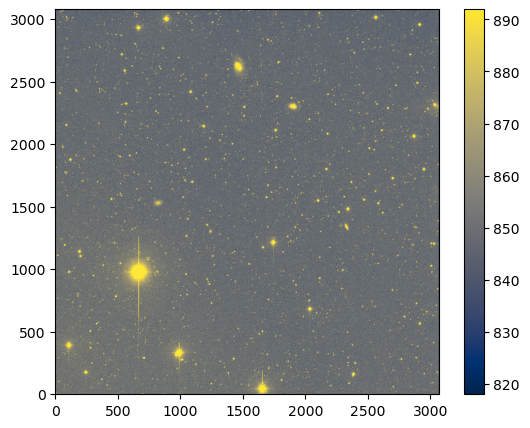

In [8]:
sci = raw.get_sciimage(qid=1, show_progress=False)
sci.show();

In [9]:
x, y = 10, 40  # Example CCD coordinates

# Convert using both methods
u_sci, v_sci = sci.xy_to_uv(x, y)
u_ztf, v_ztf = ztf_coords.xy_to_uv(x, y, sci.rcid)

# Print comparison
print(f"{'':<5} | {'WCS':>12} | {'Mapping':>12}")
print("-" * 36)
print(f"{'u':<5} | {u_sci[0]:12.4f} | {u_ztf[0]:12.4f}")
print(f"{'v':<5} | {v_sci[0]:12.4f} | {v_ztf[0]:12.4f}")

      |          WCS |      Mapping
------------------------------------
u     |    3416.3575 |    3334.2360
v     |   -3400.5939 |   -3370.6666


If we try different images, we see different offsets, mainly due to the fact that images are not calibrated to have (u,v) = (0,0) at the center of the focal plane.
Our method is therefore consistent.